# Non-Instantaneous Earth Satellite Coverage Model

This Earth Satellite Coverage Model is built atop of the [Satellite Propagation Toolkit](https://github.com/rufusclark/Satellite-Propagation-Toolkit). To execute place and run this file from the root directory of the toolkit.

Comments, Limitations and Considerations
- The data presented in this analysis is for a single time point and the distribution of satellite throughout the Earth varies greatly as a function of time
- This model does not take into account the actual observation angle of optics, but rather uses the estimated observable angle, thus overestimating the area actually observed
- This model uses all satellites under the CelesTrak "Weather & Earth Resources Satellites" header

In [1]:
# install dependencies
%pip install -r requirements.txt
%pip install cartopy
%pip install numba

# restart kernel (with new dependencies)
from IPython.display import display, Javascript
display(Javascript('IPython.notebook.kernel.restart()'))

%reset -f

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: C:\Users\rufus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<IPython.core.display.Javascript object>

In [2]:
# import all dependencies
from src import init_sats, SGP4Propagation, plot_orbital_overview, OrbitalPosition, wgs84, Satellite
from src.const import EARTH_RADIUS
from src.utility import ProgressBar, accept_any_datetime

from datetime import datetime, time, timedelta
import numpy as np
import numba

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Geod

# plt.style.use("default")
# plt.rcParams.update({
#     "mathtext.fontset": "cm",  # Computer Modern
#     "font.family": "serif"
# })

In [3]:
# Import satellite data

# Import all sats
sats = init_sats(update_sources=False)

# Number of sats
print(len(sats))

# Print out all satellite categories
sats.print_all_categories()
sats.print_all_constellations()

Using cached source groups
Loaded all 54 NORAD data sources                                                     
Loaded satcat.csv SATCAT data source
13923
{'communications satellites': 10982,
 'miscellaneous satellites': 68,
 'navigation satellites': 164,
 'scientific satellites': 56,
 'special-interest satellites': 2147,
 'weather & earth resources satellites': 506}
{'3CAT': 2,
 'AAC': 6,
 'ABS': 5,
 'AEHF': 6,
 'AEROCUBE': 11,
 'AETHER': 2,
 'AIST': 2,
 'AL': 3,
 'ALOS': 3,
 'ALSAT': 4,
 'AMAZONAS': 5,
 'AMC': 6,
 'AMOS': 3,
 'ANIK': 4,
 'ANSER': 3,
 'APRIZESAT': 10,
 'APSTAR': 6,
 'ARABSAT': 4,
 'ARIANE': 3,
 'ARIRANG': 3,
 'ARKTIKA': 2,
 'ARSAT': 2,
 'ARVAKER': 3,
 'ASBM': 2,
 'ASIASAT': 6,
 'ASNARO': 2,
 'ASTRA': 12,
 'ASTROCAST': 12,
 'ATHENA': 3,
 'ATLAS': 4,
 'AZERSPACE': 2,
 'BADR': 3,
 'BB': 2,
 'BEIDOU': 112,
 'BEIJING': 2,
 'BLACKJACK': 4,
 'BRITE': 4,
 'BRO': 13,
 'BSAT': 5,
 'BUFENG': 2,
 'CALSPHERE': 3,
 'CANX': 3,
 'CAPELLA': 6,
 'CARTOSAT': 7,
 'CBERS': 3,
 'CE': 2,
 

In [4]:
# Filter sats
# sats = sats.filter(lambda sat: sat.constellation == "SENTINEL")
# sats = sats.filter(lambda sat: sat.constellation == "SENTINEL").limit(1)
# sats = sats.filter(lambda sat: sat.name in ["SENTINEL-2A", "SENTINEL-2B"])
sats = sats.filter(lambda sat: sat.name in ["SENTINEL-1C", "SENTINEL-1D"])

# Number of sats
print(sats)

<Sats n=2>


In [5]:
# Ciara data
lookup_dict = {"FLOCK": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "SKYSAT": {"FoV half angle degs": 7.5, "night mode": False, "instrument": "optical"}, "ICEYE": {"FoV half angle degs": 4.5, "night mode": True, "instrument": "radar"}, "CAPELLA": {"FoV half angle degs": 15, "night mode": True, "instrument": "radar"}, "SENTINEL": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}, "WORLDVIEW": {"FoV half angle degs": 1.5, "night mode": False, "instrument": "optical"}, "OTHER": {"FoV half angle degs": 15, "night mode": False, "instrument": "optical"}}

def half_angle(sat: Satellite) -> float:
    """lookup half angle based on Ciara data on constellations field of view"""
    # Didn't realise these weren't the same as Ciara's data :(
    if sat.name.startswith("SENTINEL-1"):
        return 10.2
    if sat.name.startswith("SENTINEL-2"):
        return 10.3

    lookup_dict_keys = list(lookup_dict.keys())
    constellation = sat.constellation

    return lookup_dict[constellation if constellation in lookup_dict_keys else "OTHER"]["FoV half angle degs"]

def swath_ground_radius(theta_rad, h_km):
    # calculate angle and radius of horizon
    theta_horizon = np.asin(EARTH_RADIUS / (EARTH_RADIUS + h_km))
    r_horizon = EARTH_RADIUS * np.acos(EARTH_RADIUS / (EARTH_RADIUS + h_km))

    arg = (EARTH_RADIUS + h_km)/EARTH_RADIUS * np.sin(theta_rad)
    arg_clipped = np.clip(arg, -1, 1)

    # vectorised approach for future use
    return np.where(
        theta_rad <= theta_horizon,
        EARTH_RADIUS * (np.asin(arg_clipped) - theta_rad),
        r_horizon
    )

In [6]:
# Calculate the time to go across one swath width (diameter)

# ! Not verified

sat = sats.sats[0]

pos: OrbitalPosition = SGP4Propagation().propagate(sat, datetime.combine(datetime(2025, 11, 27).date(), time(12)))[0]

alt = pos.geo.alt
theta = np.radians(half_angle(sat))
swath_width = 2 * swath_ground_radius(theta, alt)
speed = pos.geo.total_velocity()
swath_width_pass_time = swath_width / speed

minimum_time_period_considered_a_pass = (swath_width * np.sqrt(1 - ((np.pi**2)/16)) ) / speed

print(f"{alt=:.3f}km\n{speed=:.3f}km/s\n{swath_width=:.3f}km\n{swath_width_pass_time=:.3f}s\n{minimum_time_period_considered_a_pass=:.3f}s")

alt=711.237km
speed=7.582km/s
swath_width=256.425km
swath_width_pass_time=33.819s
minimum_time_period_considered_a_pass=20.934s


In [18]:
# Get satellite positional data at given time (propagate and process)

# propagation time - you want this to be within 2 weeks +/- of current data epoch or the output will be unreliable
t0 = datetime.combine(datetime(2025, 11, 27).date(), time(12)) # today at noon
t1 = t0 + timedelta(days=1)
dt = timedelta(seconds=30)
# dt = timedelta(seconds=int(swath_width_pass_time))
steps = int((t1 - t0) / dt) + 1
num_sats = len(sats)
chunk_size = 10000

print(f"steps per sat = {steps}, total steps (number of SGP4 propagations) = {steps * num_sats}")

bar = ProgressBar(len(sats) * steps)

# setup times
sat_times_dt = [t0 + dt * i for i in range(steps)]
sat_times_skyfield = accept_any_datetime(sat_times_dt)
sat_times_skyfield_chunks = [sat_times_skyfield[i:i+chunk_size] for i in range(0, len(sat_times_skyfield), chunk_size)]

# setup np.arrays
sats_lats_deg = np.zeros((num_sats, steps), dtype=np.float64)
sats_lons_deg = np.zeros((num_sats, steps), dtype=np.float64)
sats_swath_radii = np.zeros((num_sats, steps), dtype=np.float32)
sat_times = np.array([t.timestamp() for t in sat_times_dt], dtype=np.int64)

# for each sat
for sat_pos_idx, sat in enumerate(sats.sats):

    # TODO: Utilise this massively in the manager or elsewhere

    FoV_rad = np.radians(half_angle(sat))

    # chunk for times
    for sat_idx, start in enumerate(range(0, steps, chunk_size)):
        bar.update(sat_pos_idx * steps + start)

        end = min(start + chunk_size, steps)

        sat_pos = sat._sat.at(sat_times_skyfield_chunks[sat_idx])
        geo_pos = wgs84.geographic_position_of(sat_pos)

        sats_lats_deg[sat_pos_idx, start:end] = geo_pos.latitude.degrees # type: ignore
        sats_lons_deg[sat_pos_idx, start:end] = geo_pos.longitude.degrees # type: ignore
        sats_swath_radii[sat_pos_idx, start:end] = swath_ground_radius(FoV_rad, geo_pos.elevation.km)

bar.update(bar.tasks)

steps per sat = 2881, total steps (number of SGP4 propagations) = 5762
[####################] 100.00% (eta: 0:00:00)


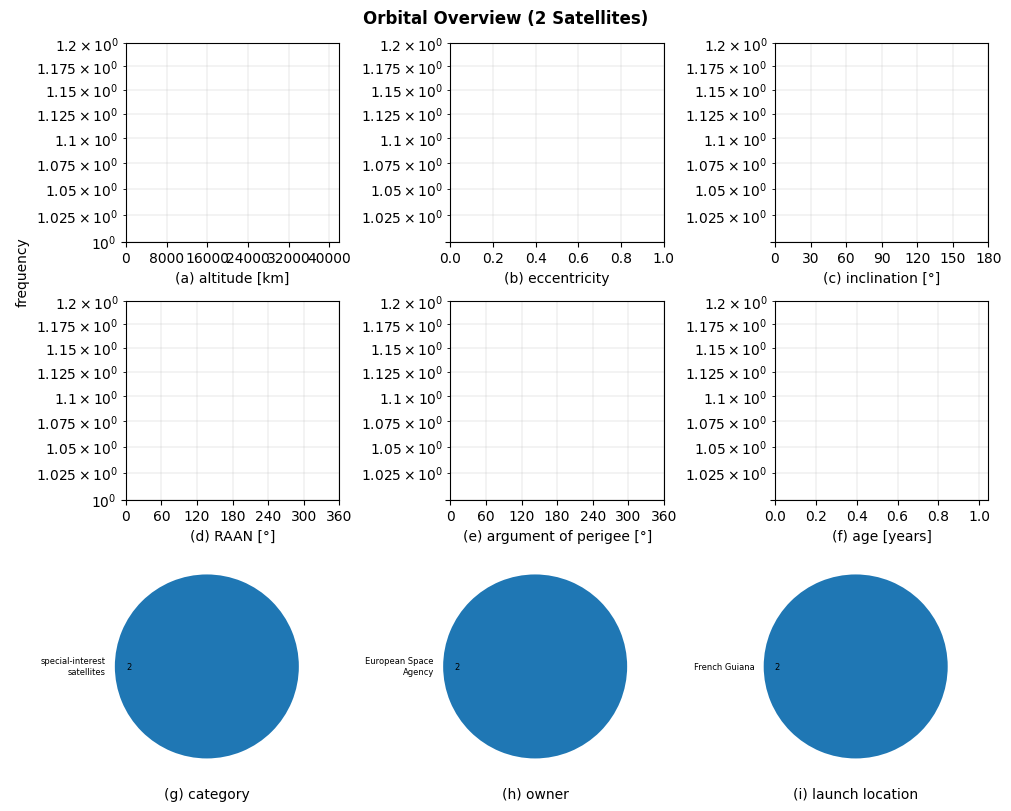

In [8]:
# Optionally, plot orbital overview

plot_orbital_overview(SGP4Propagation().propagate(sats, t0))

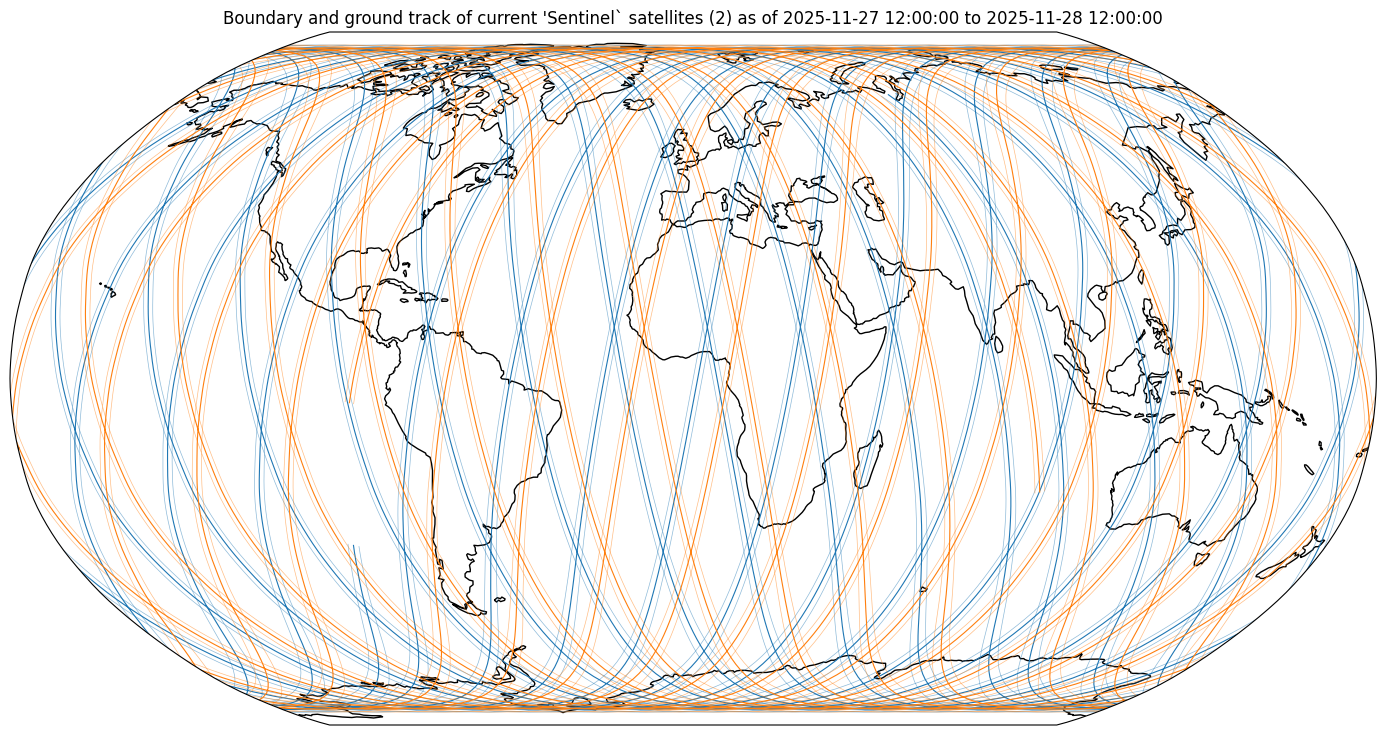

In [19]:
# Plot the boundary of coverage on a 2D map

# Earth model for geodesics
geod = Geod(ellps="WGS84")

# Plot
fig = plt.figure(figsize=(18, 9))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

for sat_lats_deg, sat_lons_deg, sat_swath_radius in zip(sats_lats_deg, sats_lons_deg, sats_swath_radii):
    line, = ax.plot(sat_lons_deg, sat_lats_deg, transform=ccrs.Geodetic(), linewidth=0.8)
    colour = line.get_color()

    # compute ground track bearings
    bearings = geod.inv(sat_lons_deg[:-1], sat_lats_deg[:-1],
                        sat_lons_deg[1:], sat_lats_deg[1:])[0]
    
    # pad to same length
    bearings = np.append(bearings, bearings[-1])
    
    # left and right swath bearings
    left_bearings  = bearings + 90
    right_bearings = bearings - 90

    # km to m
    dist = sat_swath_radius * 1000.0
    left_lons, left_lats, _ = geod.fwd(sat_lons_deg, sat_lats_deg, left_bearings, dist)
    right_lons, right_lats, _ = geod.fwd(sat_lons_deg, sat_lats_deg, right_bearings, dist)

    # plot boundaries
    ax.plot(left_lons, left_lats,  transform=ccrs.Geodetic(),
            linewidth=0.5, color=colour, alpha=0.5)
    ax.plot(right_lons, right_lats, transform=ccrs.Geodetic(),
            linewidth=0.5, color=colour, alpha=0.5)

plt.title(f"Boundary and ground track of current 'Sentinel` satellites ({len(sats)}) as of {t0} to {t1}")

plt.show()

In [10]:
# define fibonacci grid - almost perfectly distributed points on a sphere
# https://extremelearning.com.au/how-to-evenly-distribute-points-on-a-sphere-more-effectively-than-the-canonical-fibonacci-lattice/

resolution_km = 50

# calculate the number of points needed
n = np.ceil((4 * np.pi * EARTH_RADIUS**2)/(resolution_km)**2)

# generate fibonacci sphere coordinates
sat_idx = np.arange(n)
golden_ratio = (1 + 5**0.5)/2
theta = 2 * np.pi * sat_idx / golden_ratio
phi = np.arccos(1 - 2*(sat_idx)/n)

# convert to spherical coordinates
x, y, z = np.cos(theta) * np.sin(phi), np.sin(theta) * np.sin(phi), np.cos(phi)

# convert to lat/lon (degrees)
grid_lats = np.degrees(np.arcsin(y))
grid_lons = np.degrees(np.arctan2(z, x))

# Spot check instead
# grid_lats = np.array([55, 40, 11, 0])
# grid_lons = np.array([-3.5, -3.5, -4.3, 0])

# rectangular lat, lon grid
# lats = np.arange(-90, 91, 0.5)
# lons = np.arange(-180, 181, 0.5)
# lat_grid, lon_grid = np.meshgrid(lats, lons)
# grid_lats = lat_grid.ravel()
# grid_lons = lon_grid.ravel()

n = len(grid_lats)
print(f"Total grid points: {n:.0f}")

Total grid points: 204026


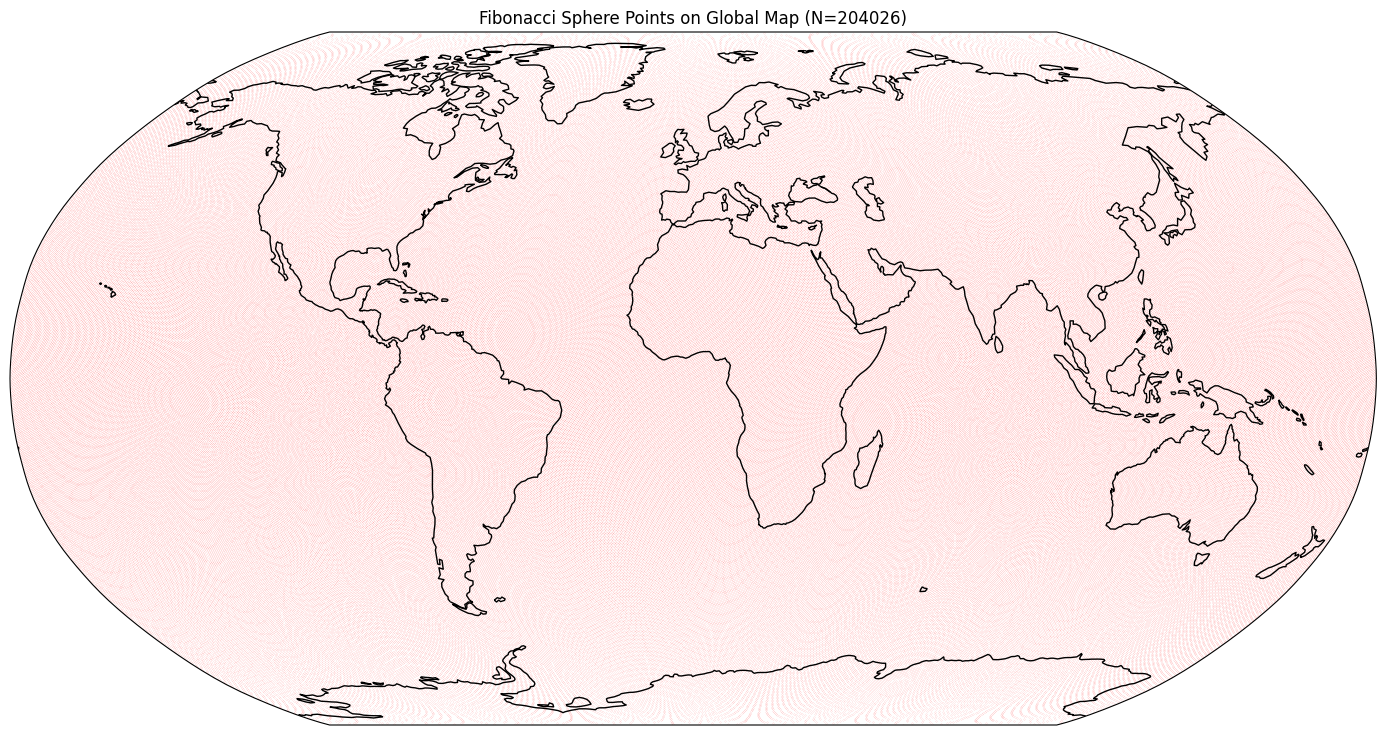

In [11]:
# plot grid

# Plot
fig = plt.figure(figsize=(18, 9))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

# Plot the points
s = 0.005 if n > 100 else 50
ax.scatter(grid_lons, grid_lats, s=s, color='red',alpha=0.7,transform=ccrs.Geodetic())

plt.title(f"Fibonacci Sphere Points on Global Map (N={len(grid_lats)})")
plt.show()

In [12]:
# coverage calculations

# ! This model does not support non-integer seconds dt (or sub-second dt)

# setup
TIME_TYPE = np.int64
TIME_TYPE_MAX = np.iinfo(TIME_TYPE).max
TIME_TYPE_MIN = np.iinfo(TIME_TYPE).min
CENTRAL_PASS_TIME_TYPE = np.float64

# coverage model configuration
MIN_SEPARATION_TIME = TIME_TYPE(10 * dt.total_seconds()) # minimum time [seconds] between passes
MIN_PASS_DURATION = TIME_TYPE(1.5 * dt.total_seconds()) # minimum duration [seconds] of pass to be considered a pass
# ! this effectively remove single point noise

@numba.vectorize([numba.float64(numba.float64, numba.float64, numba.float64, numba.float64)], target="cpu", cache=True)
def great_circle_distance(lat1, lon1, lat2, lon2):
    """computes the great-circle distance in kilometres.

    uses the spherical law of cosines (accurate when distance is > 1m) otherwise you haversine formula

    typical error vs WGS-64 Ellipsoid is 0.1%-0.5%
    """

    dlon = lon2 - lon1

    return EARTH_RADIUS * np.acos(
        np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(dlon)
    )

@numba.njit(cache=True)
def pass_and_coverage_logic(
    is_covered,
    sat_time,
    sat_coverage,
    sat_passes,
    sat_pass_start_time,
    sat_pass_end_time,
    sat_first_central_pass_time,
    sat_last_central_pass_time
):
    """brains of the operation.

    processing the data coverage to extract the following data points for further analysis. these are all mutated in place:
    - `sat_coverage`, the number of times a grid points is within radius
    - `sat_passes`, the number of times a grid point has a pass (see PASS logic below)
    - `sat_first_central_pass_time`, the central time of the first pass
    - `sat_last_central_pass_time`, the central time of the last pass

    passes are defined by:
    - `MIN_SEPARATION_TIME`, the minimum time between subsequent passes (this can be used to remove noise)
    - `MIN_PASS_DURATION`, the minimum duration for a visit to be considered a pass

    both of these are VERY sensitive to changes in step duration and grid size. duplicate points at the same time are ignored.

    Args:
        is_covered: 1d numpy array
        sat_time: scalar
        sat_coverage: 1d numpy array
        sat_passes: 1d numpy array
        sat_pass_start_time: 1d numpy array
        sat_pass_end_time: 1d numpy array
        sat_first_central_pass_time: 1d numpy array
        sat_last_central_pass_time: 1d numpy array
    """
    # precompute with vectorisation to optimise for most common path
    # not (not covered and time between passes is less than MIN_SEPARATION_TIME)
    mask = ~ ((~ is_covered) & ((sat_time - sat_pass_end_time) < MIN_SEPARATION_TIME))

    # for each grid point
    for idx in range(len(is_covered)):
        if mask[idx]:
            # is grid point covered by the sat swath radius
            if is_covered[idx]:
                # is this the first time for this pass
                if sat_pass_end_time[idx] == TIME_TYPE_MAX:
                    sat_pass_start_time[idx] = sat_time
                sat_pass_end_time[idx] = sat_time
            else:
                sat_coverage[idx] += 1
                # is the pass duration greater than MIN_PASS_DURATION
                if (sat_pass_end_time[idx] - sat_pass_start_time[idx]) > MIN_PASS_DURATION:
                    sat_last_central_pass_time[idx] = (sat_pass_start_time[idx] + sat_pass_end_time[idx]) / 2
                    # is this the first pass recorded
                    if sat_passes[idx] == 0:
                        sat_first_central_pass_time[idx] = sat_last_central_pass_time[idx]
                    sat_passes[idx] += 1
                sat_pass_end_time[idx] = TIME_TYPE_MAX

numba.set_num_threads(4)
@numba.njit(parallel=True)
def coverage_calculations(
    sats_lats_deg,
    sats_lons_deg,
    sats_swath_radii,
    sat_times,
    grid_lats,
    grid_lons,
    sat_names: list[str]
):
    # setup output values
    output_shape = (sats_lats_deg.shape[0], grid_lons.shape[0])
    sats_coverage = np.zeros(output_shape, dtype=np.uint16) # number of intersections
    sats_passes = np.zeros(output_shape, dtype=np.uint16) # number of passes (consider pass logic)
    sats_pass_start_time = np.full(output_shape, TIME_TYPE_MIN, dtype=TIME_TYPE) # start time of last pass
    sats_pass_end_time = np.full(output_shape, TIME_TYPE_MAX, dtype=TIME_TYPE) # end time of last pass
    sats_first_central_pass_time = np.zeros(output_shape, dtype=CENTRAL_PASS_TIME_TYPE) # central time of first pass
    sats_last_central_pass_time = np.zeros(output_shape, dtype=CENTRAL_PASS_TIME_TYPE) # central time of last pass

    # precompute values for great circle calculations
    grid_lats_rad = np.radians(grid_lats)
    grid_lons_rad = np.radians(grid_lons)

    # setup progress bar
    # outer_loops = sats_lats_deg.shape[0] # type: ignore
    # inner_loops = sats_lats_deg.shape[1] # type: ignore
    # bar = ProgressBar(outer_loops * inner_loops)

    # for each sat
    for sat_idx in numba.prange(sats_lats_deg.shape[0]):
        sat_lats_deg = sats_lats_deg[sat_idx]
        sat_lons_deg = sats_lons_deg[sat_idx]
        sat_swath_radii = sats_swath_radii[sat_idx]

        # ! only consider descending passes
        if sat_names[sat_idx].startswith("SENTINEL-2"):
            sat_lats_deg = np.ascontiguousarray(sat_lats_deg)
            descending_mask = np.diff(sat_lats_deg) < 0
            sat_lats_deg = sat_lats_deg[:-1][descending_mask]
            sat_lons_deg = sat_lons_deg[:-1][descending_mask]
            sat_swath_radii = sat_swath_radii[:-1][descending_mask]
            times = sat_times[:-1][descending_mask]
        else:
            times = sat_times

        # for each sat position
        for sat_pos_idx, (sat_lat_deg, sat_lon_deg, sat_swath_radius, sat_time) in enumerate(zip(sat_lats_deg, sat_lons_deg, sat_swath_radii, times)):
            
            # if sat_pos_idx % (steps // 4) == 0:
            #     bar.update(sat_idx * inner_loops + sat_pos_idx)

            # performance optimisations

            # pre-convert
            sat_lat_rad = np.radians(sat_lat_deg)
            sat_lon_rad = np.radians(sat_lon_deg)

            # bounding box calculations
            central_angle = sat_swath_radius / EARTH_RADIUS

            # latitude mask
            lat_mask = np.abs(grid_lats_rad - sat_lat_rad) <= central_angle

            # end of performance optimisations

            # Great circle distance
            dist = great_circle_distance(grid_lats_rad[lat_mask], grid_lons_rad[lat_mask], sat_lat_rad, sat_lon_rad)

            # check if grid point is within radius (masked only)
            within_swath_mask = dist <= sat_swath_radius

            # if grid point is within radius (all points)
            full_within_swatch_mask = np.zeros(grid_lats.shape, dtype=np.bool)
            full_within_swatch_mask[lat_mask] = within_swath_mask

            pass_and_coverage_logic(
                is_covered=full_within_swatch_mask,
                sat_time=sat_time,
                sat_coverage=sats_coverage[sat_idx],
                sat_passes=sats_passes[sat_idx],
                sat_pass_start_time=sats_pass_start_time[sat_idx],
                sat_pass_end_time=sats_pass_end_time[sat_idx],
                sat_first_central_pass_time=sats_first_central_pass_time[sat_idx],
                sat_last_central_pass_time=sats_last_central_pass_time[sat_idx],
            )
    
    return (
        sats_coverage,
        sats_passes,
        sats_first_central_pass_time,
        sats_last_central_pass_time
    )

sats_coverage, sats_passes, sats_first_central_pass_time, sats_last_central_pass_time = coverage_calculations(
    sats_lats_deg=sats_lats_deg,
    sats_lons_deg=sats_lons_deg,
    sats_swath_radii=sats_swath_radii,
    sat_times=sat_times,
    grid_lats=grid_lats,
    grid_lons=grid_lons,
    sat_names=[sat.name for sat in sats.sats]
)

In [13]:
# Post Coverage Data Processing

def remove_outliers_by_lat(value, bin_width_deg, lower_percentile, upper_percentile):
    """remove outliers from the provided `value` by putting into latitude bins of `bin_width_deg` and then replacing data that falls outside of `lower_percentile`% and `upper_percentile`% with the median within each bin.

    Args:
        value: 2D np.array of size (num sats, num grid points)
        bin_width_deg: bin width, deg
        lower_percentile: lower percentile %
        upper_percentile: upper percentile %

    Raises:
        ValueError: not enough data points in a bin

    Returns:
        copy of `value` without outliers
    """
    cleaned = value.copy()

    lat_bins = np.arange(-90, 90, bin_width_deg)

    for b in lat_bins:
        mask = (grid_lats > b) & (grid_lats < b + bin_width_deg)
        if np.sum(mask) < 10:
            raise ValueError(f"too few points to compute percentiles reliably: n={np.sum(mask)}")
        
        vals = value[:, mask]
        lower_percentiles = np.percentile(vals, lower_percentile, axis=1, keepdims=True)
        upper_percentiles = np.percentile(vals, upper_percentile, axis=1, keepdims=True)
        median = np.median(vals, axis=1, keepdims=True)

        cleaned[:, mask] = np.where(
            (vals < lower_percentiles) | (vals > upper_percentiles),
            median,
            vals
        )
    return cleaned

with np.errstate(divide="ignore", invalid="ignore"):
    # clean data and remove outliers
    sats_coverage = remove_outliers_by_lat(sats_coverage, 1, 0, 95)
    
    # calculate mean revisit days
    mean_revisit_days_by_sat = np.where(sats_passes > 1, ((sats_last_central_pass_time - sats_first_central_pass_time)/(60*60*24)) / sats_passes, np.nan)

    # remove outliers (artifacts) from mean revisit days
    mean_revisit_days_by_sat = remove_outliers_by_lat(mean_revisit_days_by_sat, 1, 0, 100)

    # constellation mean revisit period (using harmonic sum)
    revisit_frequency_constellation = np.nansum(1 / mean_revisit_days_by_sat, axis=0)
    mean_revisit_days_constellation = (1 / revisit_frequency_constellation)

# constellation sats_coverage
constellation_coverage = np.nansum(sats_coverage, axis=0)

if n < 10:
    for lat, lon, mean_revisit_days in zip(grid_lats, grid_lons, mean_revisit_days_constellation):
        print(f"{lat=:.3f}, {lon=:.3f}, {mean_revisit_days=:.3f}")

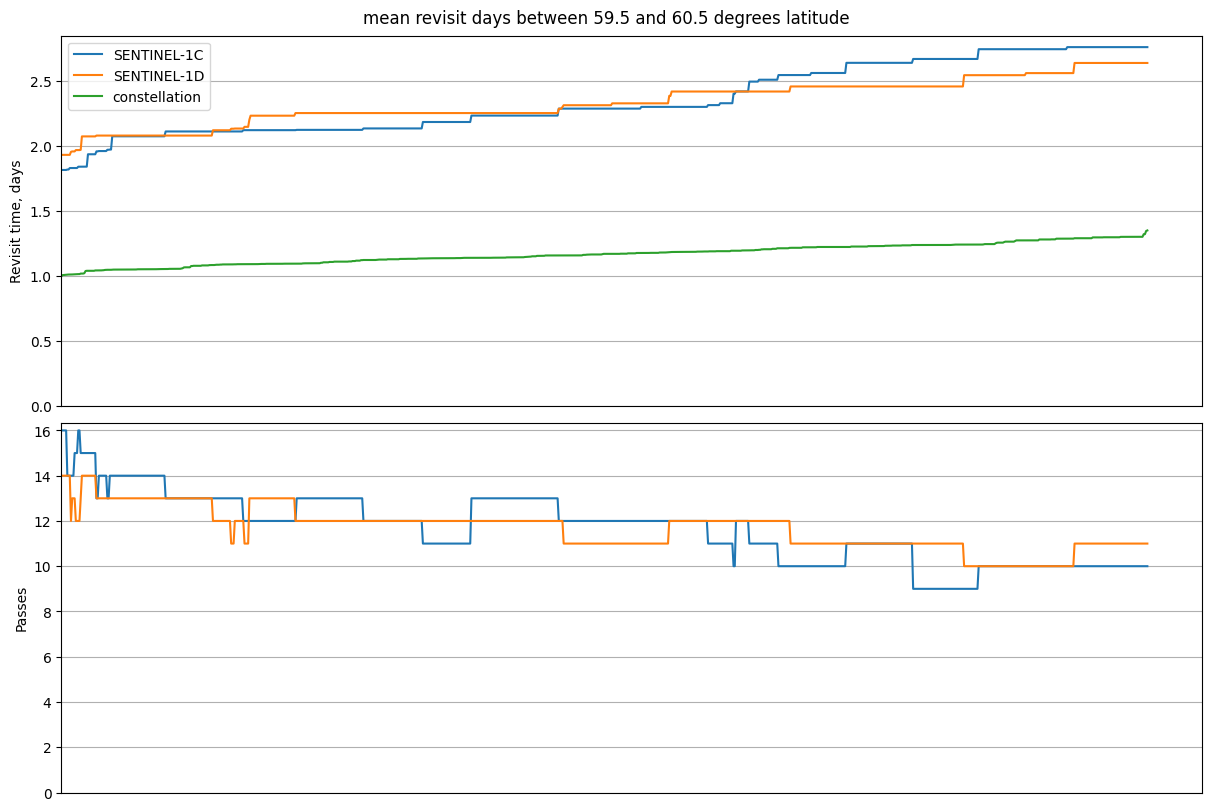

In [14]:
# Plot by bin

lat_width = 1
lat_centre = 60
min_lat = lat_centre - 0.5 * lat_width
max_lat = lat_centre + 0.5 * lat_width
mask = ~ ((grid_lats > max_lat) | (grid_lats < min_lat))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 8), layout="compressed")
for name, data, data2 in zip([sats.sats[0].name, sats.sats[1].name, "constellation"], [mean_revisit_days_by_sat[0], mean_revisit_days_by_sat[1], mean_revisit_days_constellation], [sats_passes[0], sats_passes[1], None]):
    order = np.argsort(data[mask])
    y_data = data[mask][order]
    x_data = np.arange(len(y_data))
    ax[0].plot(x_data, y_data, label=name)

    if data2 is not None:
        y_data2 = data2[mask][order]
        ax[1].plot(x_data, y_data2, label=name)
ax[0].legend()
ax[0].set_xlim(0, None)
ax[0].set_ylim(0, None)
ax[0].set_xticks([])
ax[0].set_ylabel("Revisit time, days")
ax[0].grid()
ax[1].set_xlim(0, None)
ax[1].set_ylim(0, None)
ax[1].set_xticks([])
ax[1].set_ylabel("Passes")
ax[1].grid()
_ = fig.suptitle(f"mean revisit days between {min_lat} and {max_lat} degrees latitude")

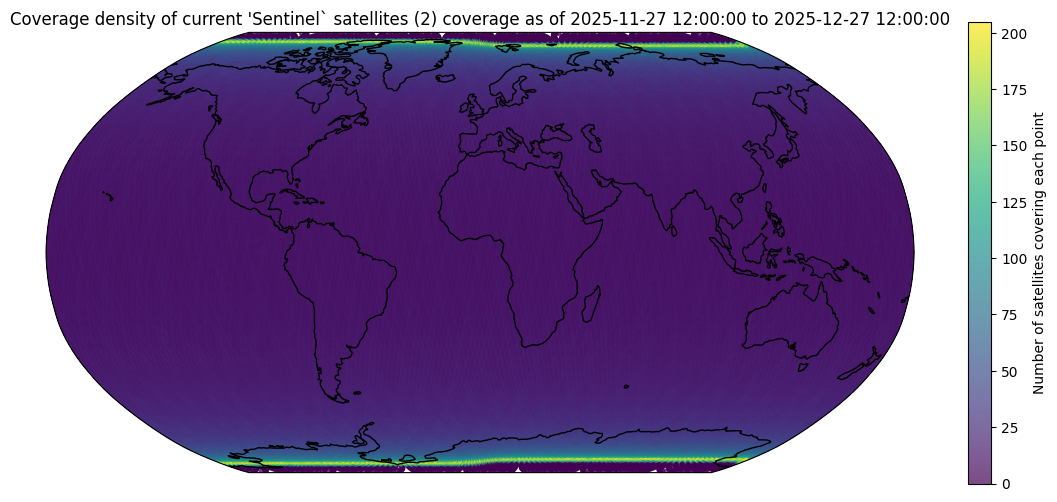

In [15]:
# Plot coverage

fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
s = 10 if n > 100 else 50
sc = ax.scatter(grid_lons, grid_lats, c=constellation_coverage, s=s, cmap="viridis", alpha=0.7, transform=ccrs.Geodetic())
plt.colorbar(sc, orientation="vertical", label="Number of satellites covering each point")
plt.title(f"Coverage density of current 'Sentinel` satellites ({len(sats)}) coverage as of {t0} to {t1}")
plt.show()

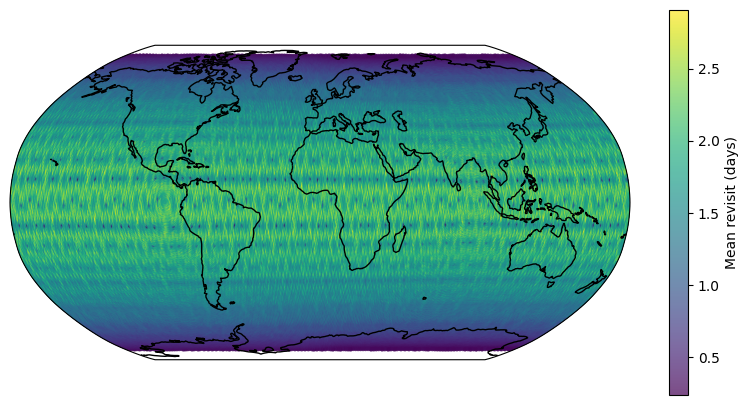

In [16]:
# Plot mean revisit time

# Clean up around 80 deg
# clean up artifacts near the poles
near_poles_mask = np.abs(grid_lats) > 79.5
near_poles_mode = np.unique(mean_revisit_days_constellation[near_poles_mask], return_counts=True)[0][np.argmax(np.unique(mean_revisit_days_constellation[near_poles_mask], 
return_counts=True)[1])]
mean_revisit_days_constellation[near_poles_mask] = near_poles_mode

cmap = plt.cm.viridis # type: ignore
cmap = cmap.copy()
cmap.set_over("yellow")

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global() # type: ignore
ax.coastlines() # type: ignore

# ! TESTING ONLY
lat_mask = mean_revisit_days_constellation > 0

s = 10 if n > 100 else 50
sc = ax.scatter(
    grid_lons[lat_mask],
    grid_lats[lat_mask],
    c=mean_revisit_days_constellation[lat_mask],
    cmap=cmap,
    s=5,
    alpha=0.7,
    # vmax=6,
    transform=ccrs.PlateCarree(),
)
cb = plt.colorbar(sc, orientation="vertical", label="Mean revisit (days)")
cb.ax.tick_params(labelsize=10)
plt.savefig("./images/ciara paper/temp1.png")
plt.show()

# ax = plt.axes(projection=ccrs.Robinson())
# ax.set_global()
# ax.coastlines()
# s = 10 if n > 100 else 50
# sc = ax.scatter(grid_lons, grid_lats, c=mean_revisit_time, s=s, cmap="viridis", alpha=0.7, transform=ccrs.Geodetic(), vmin=0, vmax=percentile_mean_revisit_time)
# plt.colorbar(sc, orientation="vertical", label="Mean revisit [days]")
# # plt.title(f"Mean revisit time of current 'sentinel` satellites ({len(sats)}) coverage as of {t0} to {t1}")
# plt.show()

C:\Users\rufus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


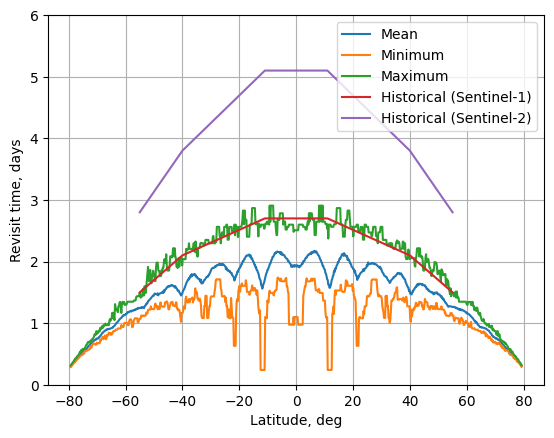

mean revisit at equator = nan


In [17]:
# plot mean revisit time vs latitude

# Define lat bins
lat_bins = np.arange(-90, 91, 0.2)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
num_bins = len(lat_bins) - 1

# preallocate arrays
mean_revisit_by_lat = np.full(num_bins, np.nan, dtype=np.float64)
min_revisit_by_lat = np.full(num_bins, np.nan, dtype=np.float64)
max_revisit_by_lat  = np.full(num_bins, np.nan, dtype=np.float64)

# remove outliers
for sat_idx in range(num_bins):
    lat_mask = (grid_lats >= lat_bins[sat_idx]) & (grid_lats < lat_bins[sat_idx+1])

    if np.any(lat_mask) and not np.all(np.isnan(mean_revisit_days_constellation[lat_mask])):
        vals = mean_revisit_days_constellation[lat_mask]

        # remove outliers by percentile
        vals_nonan = vals[~np.isnan(vals)]
        if len(vals_nonan) == 0:
            continue  # skip if no valid values

        low, high = np.percentile(vals_nonan, [0, 100])
        vals_filtered = vals_nonan[(vals_nonan >= low) & (vals_nonan <= high)]

        if len(vals_filtered) == 0:
            continue  # skip if filtering removed all values

        # Compute stats on filtered values
        mean_revisit_by_lat[sat_idx] = np.nanmean(vals_filtered)
        min_revisit_by_lat[sat_idx]  = np.nanmin(vals_filtered)
        max_revisit_by_lat[sat_idx]  = np.nanmax(vals_filtered)

# plot
plt.figure()
plt.plot(lat_centers, mean_revisit_by_lat, label="Mean")
plt.plot(lat_centers, min_revisit_by_lat, label="Minimum")
plt.plot(lat_centers, max_revisit_by_lat, label="Maximum")
plt.legend(loc="lower center")
plt.xlabel("Latitude, deg")
plt.ylabel("Revisit time, days")
plt.ylim(0, 6) # ! modified
plt.grid()
plt.savefig("./images/ciara paper/temp2.png")

plt.plot([-55, -40, -11, 0, 11, 40, 55], [1.5, 2.1, 2.7, 2.7, 2.7, 2.1, 1.5], label="Historical (Sentinel-1)")
plt.plot([-55, -40, -11, 0, 11, 40, 55], [2.8, 3.8, 5.1, 5.1, 5.1, 3.8, 2.8], label="Historical (Sentinel-2)")
plt.legend(loc="lower center")
plt.legend()
plt.show()

print(f"mean revisit at equator = {max(mean_revisit_by_lat):.3f}")